# Layer 4 – LSTM RUL Prediction

Industry-grade training notebook with data engineering, visualization, training, and evaluation.

## 1. Environment Setup

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

nb_dir = Path.cwd()
project = nb_dir
while project.parent != project:
    if (project / "backend" / "main.py").exists():
        break
    project = project.parent
backend = project / "backend"
for p in (project, backend):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

ARTIFACTS = backend / "artifacts"
DATA = project / "data"
DATASETS = DATA / "datasets"
MASTER = DATA / "master"
EVAL = DATA / "evaluation"
ARTIFACTS.mkdir(parents=True, exist_ok=True)

from scripts.synthetic_data import load_dataset, persist_all_datasets
if not (MASTER / "industrial_master.csv").exists():
    persist_all_datasets(DATASETS)

MODEL_KEY = "lstm_rul"
TRAIN_CSV = DATASETS / MODEL_KEY / "train.csv"
TEST_CSV  = DATASETS / MODEL_KEY / "test.csv"
train_npz = load_dataset(MODEL_KEY, DATASETS, split="train")
test_npz  = load_dataset(MODEL_KEY, DATASETS, split="test")
print("Project:", project)
print("Train shape:", train_npz["X"].shape)
print("Test shape:", test_npz["X"].shape)
sns.set_theme(style="whitegrid")

Project: c:\Users\ASUS\Downloads\tata-steel-round -2\industrial-agentic-maintenance-ai
Train shape: (25844, 30, 5)
Test shape: (5538, 30, 5)


## 2. Data Engineering & Exploratory Analysis

Master records: 52,000 | Assets: 520


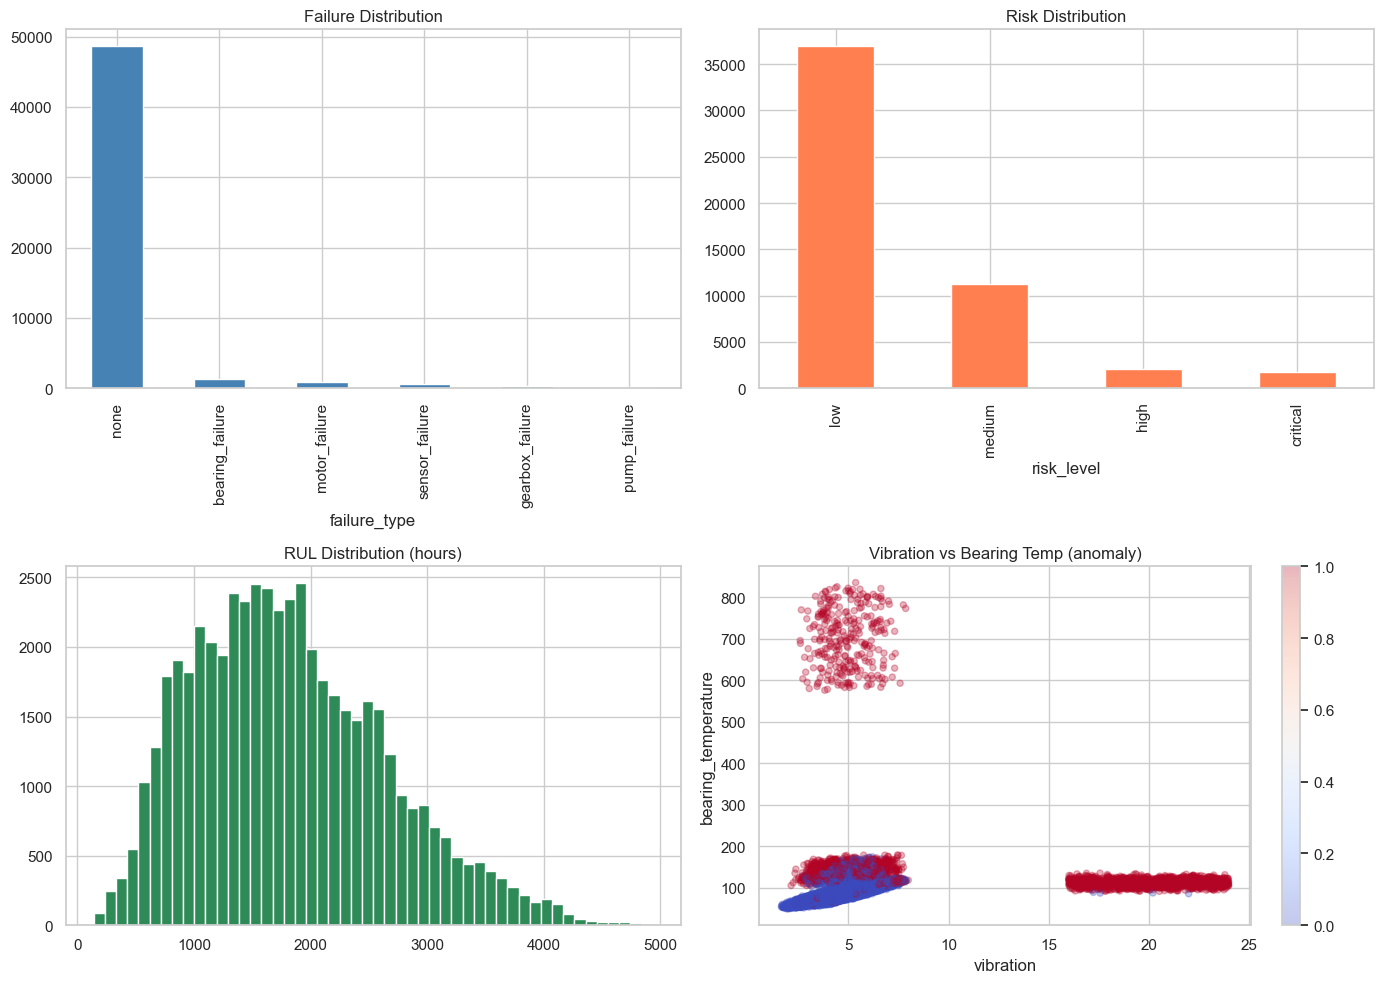

,n_sequences,seq_len,n_features
0,25844,30,5


In [2]:
# --- Data Engineering & EDA ---
master = pd.read_csv(MASTER / "industrial_master.csv", parse_dates=["timestamp"])
print(f"Master records: {len(master):,} | Assets: {master['equipment_id'].nunique()}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
master["failure_type"].value_counts().plot(kind="bar", ax=axes[0,0], title="Failure Distribution", color="steelblue")
master["risk_level"].value_counts().plot(kind="bar", ax=axes[0,1], title="Risk Distribution", color="coral")
axes[1,0].hist(master["remaining_useful_life_hours"], bins=50, color="seagreen", edgecolor="white")
axes[1,0].set_title("RUL Distribution (hours)")
master.plot.scatter(x="vibration", y="bearing_temperature", c=master["is_anomaly"], cmap="coolwarm", alpha=0.3, ax=axes[1,1])
axes[1,1].set_title("Vibration vs Bearing Temp (anomaly)")
plt.tight_layout()
plt.savefig(DATASETS / MODEL_KEY / "eda_overview.png", dpi=120)
plt.show()

if TRAIN_CSV.exists():
    try:
        from IPython.display import display
        display(pd.read_csv(TRAIN_CSV).head())
    except ImportError:
        print(pd.read_csv(TRAIN_CSV).head())

## 3. Model Training & Evaluation

MAE: 243.2h | RMSE: 315.8h | MAPE: 0.164


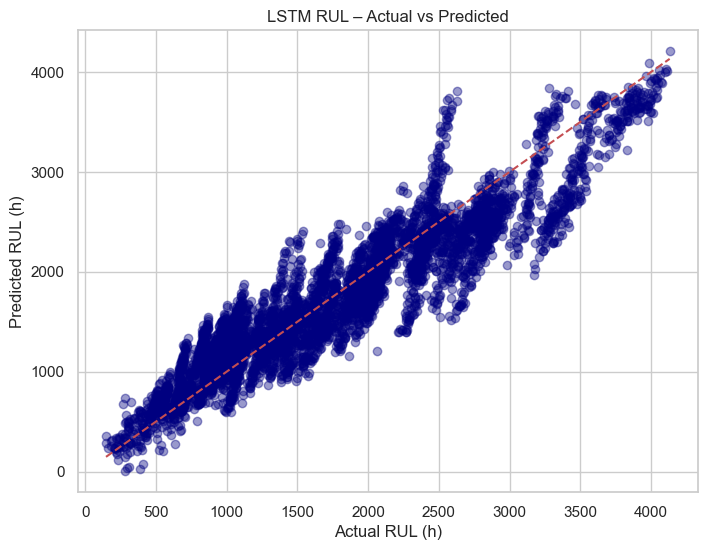

['c:\\Users\\ASUS\\Downloads\\tata-steel-round -2\\industrial-agentic-maintenance-ai\\backend\\artifacts\\lstm_rul.joblib']

In [3]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import joblib

X_train = train_npz["X"].reshape(len(train_npz["X"]), -1)
X_test = test_npz["X"].reshape(len(test_npz["X"]), -1)
y_train, y_test = train_npz["y"], test_npz["y"]
reg = GradientBoostingRegressor(n_estimators=200, random_state=42)
reg.fit(X_train, y_train)
pred = reg.predict(X_test)
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(np.mean((y_test-pred)**2))
mape = mean_absolute_percentage_error(y_test, pred)
print(f"MAE: {mae:.1f}h | RMSE: {rmse:.1f}h | MAPE: {mape:.3f}")

plt.figure(figsize=(8,6))
plt.scatter(y_test, pred, alpha=0.4, c="navy")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual RUL (h)"); plt.ylabel("Predicted RUL (h)")
plt.title("LSTM RUL – Actual vs Predicted")
plt.savefig(DATASETS / MODEL_KEY / "rul_scatter.png", dpi=120)
plt.show()

joblib.dump({"regressor": reg, "degradation_rate": float(y_train.mean()/1000)}, ARTIFACTS / "lstm_rul.joblib")

## 4. Pipeline Evaluation Metrics

In [4]:
metrics_path = EVAL / "metrics.json"
if metrics_path.exists():
    all_metrics = json.loads(metrics_path.read_text())
    print(json.dumps(all_metrics.get(MODEL_KEY, {}), indent=2))
else:
    print("Run: python scripts/generate_synthetic_data.py --skip-train  to generate metrics")

{
  "mae": 245.09313317452168,
  "rmse": 317.62956249390095,
  "mape": 0.16621427712770642,
  "summary": "MAE=245.1h RMSE=317.6h"
}


## 5. Production Deployment

Artifact saved to `backend/artifacts/`. Restart API after retraining:
```bash
cd backend && uvicorn main:app --reload --port 8000
```